<a href="https://colab.research.google.com/github/BeastAkshat123/Celebal-Technology-Data-Science-Assignments/blob/main/Week5_Akshat_Sharma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [18]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [19]:
corpus = '''
artificial intelligence is transforming modern industries
deep learning models solve complex problems
machine learning helps computers learn patterns
neural networks are widely used in artificial intelligence
cyber security protects systems from attacks
networking connects computers through the internet
ethical hacking identifies vulnerabilities in systems
deep learning improves computer vision applications
natural language processing helps machines understand text
data science combines statistics and machine learning
'''

print(corpus)


artificial intelligence is transforming modern industries
deep learning models solve complex problems
machine learning helps computers learn patterns
neural networks are widely used in artificial intelligence
cyber security protects systems from attacks
networking connects computers through the internet
ethical hacking identifies vulnerabilities in systems
deep learning improves computer vision applications
natural language processing helps machines understand text
data science combines statistics and machine learning



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [20]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)
print(tokenizer.word_index)

input_sequences = []

for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

print("Total Sequences:", len(input_sequences))

Vocabulary Size: 54
{'learning': 1, 'artificial': 2, 'intelligence': 3, 'deep': 4, 'machine': 5, 'helps': 6, 'computers': 7, 'in': 8, 'systems': 9, 'is': 10, 'transforming': 11, 'modern': 12, 'industries': 13, 'models': 14, 'solve': 15, 'complex': 16, 'problems': 17, 'learn': 18, 'patterns': 19, 'neural': 20, 'networks': 21, 'are': 22, 'widely': 23, 'used': 24, 'cyber': 25, 'security': 26, 'protects': 27, 'from': 28, 'attacks': 29, 'networking': 30, 'connects': 31, 'through': 32, 'the': 33, 'internet': 34, 'ethical': 35, 'hacking': 36, 'identifies': 37, 'vulnerabilities': 38, 'improves': 39, 'computer': 40, 'vision': 41, 'applications': 42, 'natural': 43, 'language': 44, 'processing': 45, 'machines': 46, 'understand': 47, 'text': 48, 'data': 49, 'science': 50, 'combines': 51, 'statistics': 52, 'and': 53}
Total Sequences: 54


# Padding

In [21]:
max_len = max(len(sequence) for sequence in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

print("Maximum Sequence Length:", max_len)

Maximum Sequence Length: 8


# Create X and y

In [22]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (54, 7)
y Shape: (54,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [23]:
rnn_model = Sequential([
    tf.keras.layers.Input(shape=(max_len-1,)),
    Embedding(total_words, 64),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 7, 64)          │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 54)             │         6,966 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,126 (137.21 KB)

 Trainable params: 35,126 (137.21 KB)

 Non-trainable params: 0 (0.00 B)

# Train RNN

In [24]:
rnn_history = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("RNN Training Completed")

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.0370 - loss: 3.9890
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.0556 - loss: 3.9256
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.0556 - loss: 3.8648
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1111 - loss: 3.8062
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.1111 - loss: 3.7436
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1111 - loss: 3.6757
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1481 - loss: 3.6076
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1667 - loss: 3.5428
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1481 - loss: 3.4854
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1296 - loss: 3.4136
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1481 - loss: 3.3444
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2222 - lo

# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [25]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Train LSTM

In [26]:
lstm_history = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("LSTM Training Completed")

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.0000e+00 - loss: 3.9907
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.0926 - loss: 3.9813
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.0926 - loss: 3.9739
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.0926 - loss: 3.9667
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.0926 - loss: 3.9570
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.0926 - loss: 3.9471
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.0741 - loss: 3.9347
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.0741 - loss: 3.9168
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.0741 - loss: 3.8962
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.0741 - loss: 3.8666
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.0741 - loss: 3.8238
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.0741 

# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [27]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Train GRU

In [28]:
gru_history = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("GRU Training Completed")

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.0370 - loss: 3.9890
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0926 - loss: 3.9757
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.0926 - loss: 3.9638
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0741 - loss: 3.9508
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.0741 - loss: 3.9378
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0741 - loss: 3.9230
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0741 - loss: 3.9069
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.0741 - loss: 3.8864
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.0741 - loss: 3.8637
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0741 - loss: 3.8359
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0741 - loss: 3.7979
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0741 - lo

## 📉 Compare Training Loss

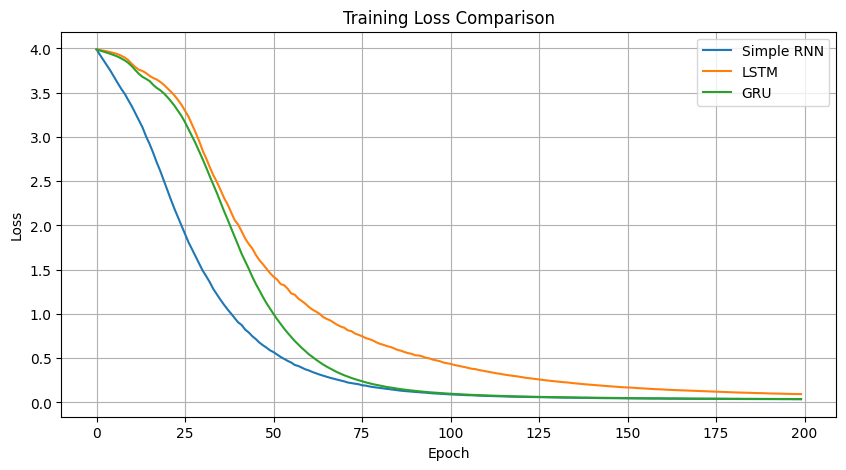

In [29]:
plt.figure(figsize=(10,5))

plt.plot(rnn_history.history['loss'], label='Simple RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True)

plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [30]:
def generate_text(model, seed_text, next_words=10):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=0),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

## 🧪 Generate Text Samples

In [31]:
print("RNN Output:")
print(generate_text(rnn_model, "deep learning", 10))

print("\nLSTM Output:")
print(generate_text(lstm_model, "deep learning", 10))

print("\nGRU Output:")
print(generate_text(gru_model, "deep learning", 10))

RNN Output:
deep learning models solve complex problems identifies helps machines intelligence learning models

LSTM Output:
deep learning improves computer vision applications applications applications applications applications industries attacks

GRU Output:
deep learning models solve complex problems problems problems problems intelligence modern industries


# Accuracy Comparison

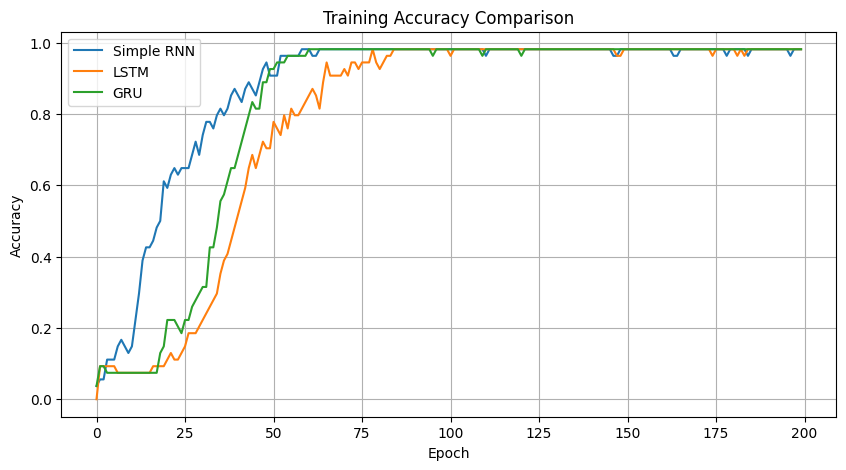

In [32]:
plt.figure(figsize=(10,5))

plt.plot(rnn_history.history['accuracy'], label='Simple RNN')
plt.plot(lstm_history.history['accuracy'], label='LSTM')
plt.plot(gru_history.history['accuracy'], label='GRU')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.grid(True)

plt.show()

# Final Conclusion

In [33]:
print("Conclusion:")
print("1. Simple RNN learns short dependencies.")
print("2. LSTM captures long-term dependencies effectively.")
print("3. GRU provides similar performance with fewer parameters.")
print("4. LSTM and GRU generally outperform Vanilla RNN.")

Conclusion:
1. Simple RNN learns short dependencies.
2. LSTM captures long-term dependencies effectively.
3. GRU provides similar performance with fewer parameters.
4. LSTM and GRU generally outperform Vanilla RNN.


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**